# healpix-resample throughput / scaling benchmark

**Purpose.** This is a standalone reference benchmark for people optimizing
`healpix-resample`'s performance. It answers the one coauthor-review request
(Thomas, review point 5) that the manuscript's existing runtime paragraphs
could not: a scaling curve across batch sizes up to 512 and 2048 patches,
rather than a single-patch runtime number.

**Scope and independence.**
- This notebook is self-contained: all wall-clock timing is measured here,
  not reused from `test-resample-paper.ipynb`, `multi_patch_latitude_validation.ipynb`,
  or `noise_sensitivity.ipynb`.
- It reuses **only already-cached** Esri patches written by
  `multi_patch_latitude_validation.ipynb` to
  `notebooks/data/multi_patch_latitude/esri_patch_cache/`. It never fetches
  new Esri tiles. If that cache is empty, run the site-manifest and at least
  a few patches of `multi_patch_latitude_validation.ipynb` first.
- It does not compute or check any reconstruction accuracy metric (no RMSE).
  It is a pure throughput/scaling reference, deliberately kept separate from
  the accuracy notebooks.

**Design.** Two batching regimes, both requested implicitly by the "operator
construction depends on geometry rather than image values, could be reused
for repeated acquisitions" claim already in the manuscript:

1. **Same pointing** (`same_pointing_shared` / `same_pointing_rebuilt`): all
   items in the batch share one patch's geometry (source `lon`/`lat`), with
   independent small radiometric noise added per item so the solves are not
   bit-identical -- this models repeated acquisitions of the same footprint
   (e.g. different dates). `shared` builds the sparse operator once and
   reuses it; `rebuilt` uses the same geometry but rebuilds the operator for
   every item anyway, as a naive baseline that isolates the benefit of reuse.
2. **Different pointing** (`different_pointing`): each item is a real,
   distinct cached patch (sampled without replacement up to the cache pool
   size, with replacement beyond it), so the operator must be rebuilt for
   every item -- this is the realistic, heterogeneous multi-region batch
   scenario, matching how `multi_patch_latitude_validation.ipynb` actually
   operates, but now measured as a controlled scaling curve.

**Expected runtime.** With the default `BATCH_SIZES` (up to 2048) and the
per-patch costs already measured on an NVIDIA A10 (construction ~0.3 s,
solve ~0.09 s at the matched configuration), the full sweep is expected to
take on the order of an hour. A quick single-batch calibration is timed
before the full sweep and used to print an estimate -- reduce `BATCH_SIZES`
before running if that estimate is too long.


In [1]:
from __future__ import annotations

import gc
import math
import os
import platform
import threading
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyproj
import torch
import zarr
from scipy.ndimage import gaussian_filter

try:
    import psutil
except ImportError:
    psutil = None

from healpix_resample import PSFResampler, fwhm_to_scale, recommend_npt


def locate_repo_root() -> Path:
    """Work both from the repository root and from `notebooks/`."""
    here = Path.cwd().resolve()
    if here.name.lower() == "notebooks":
        return here.parent
    if (here / "notebooks").is_dir():
        return here
    raise RuntimeError(
        "Run this notebook from the healpix-resample repository root "
        "or from its notebooks directory."
    )


REPO_ROOT = locate_repo_root()
NOTEBOOK_DIR = REPO_ROOT / "notebooks"

# Read-only: the Esri patch cache produced by multi_patch_latitude_validation.ipynb.
# This notebook never writes into it and never fetches new Esri tiles.
SOURCE_CACHE_DIR = NOTEBOOK_DIR / "data" / "multi_patch_latitude" / "esri_patch_cache"

# This notebook's own outputs.
TABLE_DIR = NOTEBOOK_DIR / "tables"
FIG_DIR = NOTEBOOK_DIR / "figures"
TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_SEED = 20260820
HEALPIX_LEVEL = 20
PATCH_SIZE = 256
DETECTOR_GSD_M = 10.0
OVERSAMPLE = 4                 # must match the cached geometry tag (os4)
TRUE_FWHM_M = 12.5             # matched configuration only -- this is a
                                # timing benchmark, not a PSF-mismatch study
LAMBDA = 0.01                  # matched PSF-aware damping used in the main
                                # text (Sec. IV-D); fixed-iteration CG makes
                                # timing essentially insensitive to lambda
MAX_ITER = 14
THRESHOLD = 0.1
TARGET_KERNEL_MASS = 0.99
DEVICE = "cuda:0" if torch.cuda.is_available() else "cpu"

RUN_EXPERIMENT = True  # flip to False to only load previously-written CSVs

print({
    "repo_root": str(REPO_ROOT),
    "device": DEVICE,
    "torch": torch.__version__,
    "cuda_available": torch.cuda.is_available(),
    "psutil_available": psutil is not None,
})


{'repo_root': '/home/jovyan/healpix-resample', 'device': 'cuda:0', 'torch': '2.10.0', 'cuda_available': True, 'psutil_available': True}


## 1. Discover cached patches

Metadata (`patch_id`, `patch_lat`, `patch_lon`) is read directly from each
cached patch's Zarr attributes -- this notebook does not depend on
`multi_patch_sites.csv` existing. `scene_class` and `region_id` are parsed
back out of `patch_id` (format `{scene_class}__{region_id}__r{row}c{col}`,
set by `multi_patch_latitude_validation.ipynb`); `utm_epsg` is recomputed
from `(patch_lon, patch_lat)` with the same formula that notebook uses.


In [2]:
def utm_epsg_for_lonlat(lon: float, lat: float) -> int:
    zone = min(60, max(1, int(math.floor((lon + 180.0) / 6.0)) + 1))
    return (32600 if lat >= 0 else 32700) + zone


def discover_cached_patches(cache_dir: Path) -> pd.DataFrame:
    records = []
    if not cache_dir.exists():
        return pd.DataFrame(records)
    for path in sorted(cache_dir.glob("*.zarr")):
        try:
            group = zarr.open_group(str(path), mode="r")
            attrs = dict(group.attrs)
            del group
        except Exception as exc:
            warnings.warn(f"Skipping unreadable cache entry {path}: {exc}")
            continue
        patch_id = attrs.get("patch_id")
        patch_lat = attrs.get("patch_lat")
        patch_lon = attrs.get("patch_lon")
        if patch_id is None or patch_lat is None or patch_lon is None:
            warnings.warn(f"Skipping cache entry with incomplete metadata: {path}")
            continue
        parts = str(patch_id).split("__")
        scene_class = parts[0] if len(parts) > 0 else "unknown"
        region_id = parts[1] if len(parts) > 1 else "unknown"
        records.append({
            "patch_id": patch_id,
            "scene_class": scene_class,
            "region_id": region_id,
            "patch_lat": float(patch_lat),
            "patch_lon": float(patch_lon),
            "utm_epsg": utm_epsg_for_lonlat(float(patch_lon), float(patch_lat)),
            "cache_path": str(path),
        })
    return pd.DataFrame(records)


available_patches = discover_cached_patches(SOURCE_CACHE_DIR)
if available_patches.empty:
    raise RuntimeError(
        f"No cached patches found under {SOURCE_CACHE_DIR}. Run "
        "multi_patch_latitude_validation.ipynb (at least the manifest cell "
        "and enough of the main run to populate esri_patch_cache/) before "
        "using this notebook."
    )
print(f"Found {len(available_patches)} cached patches.")
display(available_patches.groupby("scene_class")["patch_id"].nunique())
display(available_patches.head())


Found 360 cached patches.


scene_class
agriculture    90
forest         90
urban          90
water          90
Name: patch_id, dtype: int64

,patch_id,scene_class,region_id,patch_lat,patch_lon,utm_epsg,cache_path
0,agriculture__beauce__r0c0,agriculture,beauce,48.221310,1.446218,32631,/home/jovyan/healpix-resample/notebooks/data/m...
1,agriculture__beauce__r0c1,agriculture,beauce,48.222025,1.500052,32631,/home/jovyan/healpix-resample/notebooks/data/m...
2,agriculture__beauce__r0c2,agriculture,beauce,48.222715,1.553889,32631,/home/jovyan/healpix-resample/notebooks/data/m...
3,agriculture__beauce__r1c0,agriculture,beauce,48.257284,1.445128,32631,/home/jovyan/healpix-resample/notebooks/data/m...
4,agriculture__beauce__r1c1,agriculture,beauce,48.258000,1.499000,32631,/home/jovyan/healpix-resample/notebooks/data/m...


## 2. Grid and blurred-image reconstruction from cache

Reconstructs exactly the detector-grid `(lon, lat)` and blurred detector
image that `multi_patch_latitude_validation.ipynb` would build for the same
patch, using only the cached `latent_hr` array and the patch's `(lat, lon,
utm_epsg)` -- no new Esri downloads, no HEALPix children/parent bookkeeping
(not needed for a pure timing benchmark).


In [3]:
def patch_coordinate_grids_lite(patch_lat, patch_lon, utm_epsg,
                                 patch_size=PATCH_SIZE, gsd_m=DETECTOR_GSD_M):
    crs_utm = pyproj.CRS.from_epsg(int(utm_epsg))
    to_utm = pyproj.Transformer.from_crs(4326, crs_utm, always_xy=True)
    to_wgs = pyproj.Transformer.from_crs(crs_utm, 4326, always_xy=True)
    centre_x, centre_y = to_utm.transform(patch_lon, patch_lat)
    offset = (np.arange(patch_size) - (patch_size - 1) / 2) * gsd_m
    x = centre_x + offset
    y = centre_y - offset  # descending y keeps north at the top
    xx, yy = np.meshgrid(x, y)
    lon, lat = to_wgs.transform(xx, yy)
    return lon, lat


def block_mean(image, factor=OVERSAMPLE):
    ny, nx = image.shape
    if ny % factor or nx % factor:
        raise ValueError("High-resolution image is not divisible by the oversampling factor.")
    return image.reshape(ny // factor, factor, nx // factor, factor).mean(axis=(1, 3))


def load_cached_blurred_detector(cache_path, oversample=OVERSAMPLE,
                                  gsd_m=DETECTOR_GSD_M, fwhm_m=TRUE_FWHM_M):
    group = zarr.open_group(str(cache_path), mode="r")
    latent_hr = np.asarray(group["latent_hr"][:], dtype=np.float32)
    del group
    sigma_m = fwhm_m / (2.0 * np.sqrt(2.0 * np.log(2.0)))
    sigma_pixels = sigma_m / (gsd_m / oversample)
    blurred_hr = gaussian_filter(latent_hr, sigma=sigma_pixels, mode="reflect")
    return block_mean(blurred_hr, factor=oversample).astype(np.float64)


def add_batch_noise(image, snr=100.0, seed=0):
    """Small per-item radiometric noise for the same-pointing regime, purely
    so successive batch items are not bit-identical. Not a noise-robustness
    study -- see noise_sensitivity.ipynb for that.
    """
    image = np.asarray(image, dtype=np.float64)
    rng = np.random.default_rng(seed)
    noise_std = float(np.nanstd(image)) / float(snr)
    return image + noise_std * rng.standard_normal(image.shape)


## 3. Build/solve primitives (timed only in this notebook)

`build_resampler` and `solve_once` are the only two operations being timed
throughout this benchmark. Both synchronize the device (a no-op on CPU)
immediately before and after the timed region, exactly as
`multi_patch_latitude_validation.ipynb` does for its own runtime numbers.


In [4]:
def synchronize_device():
    if DEVICE.startswith("cuda") and torch.cuda.is_available():
        torch.cuda.synchronize(torch.device(DEVICE))


def reset_gpu_peak():
    if DEVICE.startswith("cuda") and torch.cuda.is_available():
        synchronize_device()
        torch.cuda.reset_peak_memory_stats(torch.device(DEVICE))


def gpu_peak_mib():
    if DEVICE.startswith("cuda") and torch.cuda.is_available():
        synchronize_device()
        return torch.cuda.max_memory_allocated(torch.device(DEVICE)) / 2**20
    return np.nan


def rss_sampler_start(process):
    """Background thread sampling CPU RSS every 50 ms, mirroring the peak-RSS
    tracking already used in multi_patch_latitude_validation.ipynb."""
    peak = [process.memory_info().rss / 2**20 if process is not None else np.nan]
    stop_event = threading.Event()

    def _sample():
        while not stop_event.wait(0.05):
            peak[0] = max(peak[0], process.memory_info().rss / 2**20)

    thread = None
    if process is not None:
        thread = threading.Thread(target=_sample, daemon=True)
        thread.start()
    return peak, stop_event, thread


def rss_sampler_stop(process, peak, stop_event, thread):
    stop_event.set()
    if thread is not None:
        thread.join()
        if process is not None:
            peak[0] = max(peak[0], process.memory_info().rss / 2**20)
    return peak[0]


def build_resampler(lon, lat, fwhm_m=TRUE_FWHM_M):
    scale_m = fwhm_to_scale(fwhm_m)
    npt = int(recommend_npt(scale_m, HEALPIX_LEVEL, target_mass=TARGET_KERNEL_MASS)["npt"])
    synchronize_device()
    started = time.perf_counter()
    resampler = PSFResampler(
        lon_deg=np.asarray(lon, dtype=np.float64).ravel(),
        lat_deg=np.asarray(lat, dtype=np.float64).ravel(),
        level=HEALPIX_LEVEL, threshold=THRESHOLD, verbose=False,
        ellipsoid="sphere", sigma_m=scale_m, Npt=npt, device=DEVICE,
    )
    synchronize_device()
    build_s = time.perf_counter() - started
    return resampler, build_s, npt


def solve_once(resampler, image, lam=LAMBDA, max_iter=MAX_ITER):
    synchronize_device()
    started = time.perf_counter()
    result = resampler.resample(
        np.asarray(image, dtype=np.float64).ravel(), lam=lam, max_iter=max_iter
    )
    synchronize_device()
    solve_s = time.perf_counter() - started
    return result, solve_s


## 4. Batch regimes

`run_same_pointing_batch` implements both `same_pointing_shared` (operator
built once, `shared_operator=True`) and `same_pointing_rebuilt`
(`shared_operator=False`, same geometry rebuilt every item -- the naive
baseline). `run_different_pointing_batch` samples real, distinct cached
patches (without replacement up to the cache pool size, with replacement
beyond it -- `unique_patches_used` records how many distinct patches were
actually behind a given batch, so results for `batch_size > pool_size`
should be read as repeated re-solves of the same small pool, not as a
larger independent sample).


In [5]:
def run_same_pointing_batch(base_lon, base_lat, base_image, batch_size,
                             shared_operator, noise_snr=100.0, seed=0):
    process = psutil.Process() if psutil is not None else None
    reset_gpu_peak()
    peak, stop_event, thread = rss_sampler_start(process)
    item_rows = []
    batch_started = time.perf_counter()

    resampler = None
    fixed_build_s = 0.0
    if shared_operator:
        resampler, fixed_build_s, npt = build_resampler(base_lon, base_lat)

    for item_index in range(batch_size):
        noisy_image = add_batch_noise(base_image, snr=noise_snr, seed=seed * 100_000 + item_index)
        if shared_operator:
            build_s = 0.0
        else:
            resampler, build_s, npt = build_resampler(base_lon, base_lat)
        result, solve_s = solve_once(resampler, noisy_image)
        item_rows.append({
            "item_index": item_index, "build_s": build_s, "solve_s": solve_s,
            "n_cells_estimated": int(len(result.cell_ids)),
        })
        del result
        if not shared_operator and torch.cuda.is_available():
            torch.cuda.empty_cache()

    batch_wall_s = time.perf_counter() - batch_started
    peak_rss_mib = rss_sampler_stop(process, peak, stop_event, thread)
    peak_gpu_mib = gpu_peak_mib()
    del resampler
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    gc.collect()
    return item_rows, batch_wall_s, fixed_build_s, peak_rss_mib, peak_gpu_mib


def run_different_pointing_batch(pool, batch_size, seed=0):
    process = psutil.Process() if psutil is not None else None
    reset_gpu_peak()
    peak, stop_event, thread = rss_sampler_start(process)
    item_rows = []
    batch_started = time.perf_counter()

    rng = np.random.default_rng(seed)
    pool_size = len(pool)
    if batch_size <= pool_size:
        chosen_idx = rng.choice(pool_size, size=batch_size, replace=False)
    else:
        chosen_idx = rng.choice(pool_size, size=batch_size, replace=True)

    for item_index, pool_idx in enumerate(chosen_idx):
        row = pool.iloc[int(pool_idx)]
        lon, lat = patch_coordinate_grids_lite(row["patch_lat"], row["patch_lon"], row["utm_epsg"])
        blurred_detector = load_cached_blurred_detector(Path(row["cache_path"]))
        resampler, build_s, npt = build_resampler(lon, lat)
        result, solve_s = solve_once(resampler, blurred_detector)
        item_rows.append({
            "item_index": item_index, "patch_id": row["patch_id"],
            "build_s": build_s, "solve_s": solve_s,
            "n_cells_estimated": int(len(result.cell_ids)),
        })
        del result, resampler
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    batch_wall_s = time.perf_counter() - batch_started
    peak_rss_mib = rss_sampler_stop(process, peak, stop_event, thread)
    peak_gpu_mib = gpu_peak_mib()
    gc.collect()
    unique_used = int(pd.Series(chosen_idx).nunique())
    return item_rows, batch_wall_s, unique_used, peak_rss_mib, peak_gpu_mib


## 5. Scaling sweep driver

Writes both a per-batch summary CSV and a per-item detail CSV, checkpointed
after every batch size so a long run can be inspected or safely interrupted.
`s_per_item` for `same_pointing_shared` includes the one-time operator build
amortized over the whole batch (`batch_wall_s / batch_size`); `mean_build_s`
for that regime is reported separately per item as `0.0` by construction
(the cost is entirely in `fixed_build_s`) so the two are not double-counted
when comparing regimes.


In [6]:
BATCH_SIZES = [1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024, 2048]
N_BATCH_REPEATS = 1  # raise for tighter estimates, at the cost of runtime

REGIME_LABELS = {
    "same_pointing_shared": "Same pointing, shared operator",
    "same_pointing_rebuilt": "Same pointing, rebuilt operator",
    "different_pointing": "Different pointing (real cached patches)",
}


def _summarize_items(items, regime, batch_size, repeat, batch_wall_s,
                      fixed_build_s, unique_used, pool_size, peak_rss_mib, peak_gpu_mib):
    return {
        "regime": regime, "batch_size": batch_size, "repeat": repeat,
        "batch_wall_s": batch_wall_s, "fixed_build_s": fixed_build_s,
        "mean_build_s": float(np.mean([r["build_s"] for r in items])),
        "mean_solve_s": float(np.mean([r["solve_s"] for r in items])),
        "median_solve_s": float(np.median([r["solve_s"] for r in items])),
        "s_per_item": batch_wall_s / batch_size,
        "items_per_hour": 3600.0 * batch_size / batch_wall_s if batch_wall_s > 0 else np.nan,
        "peak_rss_mib": peak_rss_mib, "peak_gpu_memory_mib": peak_gpu_mib,
        "unique_patches_used": unique_used, "pool_size": pool_size,
    }


def run_scaling_sweep(pool, batch_sizes=BATCH_SIZES, n_repeats=N_BATCH_REPEATS):
    if pool.empty:
        raise RuntimeError("No cached patches available for the sweep.")
    base_row = pool.iloc[0]
    base_lon, base_lat = patch_coordinate_grids_lite(
        base_row["patch_lat"], base_row["patch_lon"], base_row["utm_epsg"]
    )
    base_image = load_cached_blurred_detector(Path(base_row["cache_path"]))
    pool_size = len(pool)

    summary_rows = []
    item_rows_all = []

    for batch_size in batch_sizes:
        for repeat in range(n_repeats):
            seed = RANDOM_SEED + 1000 * batch_size + repeat

            print(f"[same_pointing_shared]   batch={batch_size:5d} repeat={repeat}", flush=True)
            items, wall_s, fixed_build_s, rss, gpu = run_same_pointing_batch(
                base_lon, base_lat, base_image, batch_size, shared_operator=True, seed=seed
            )
            for row in items:
                row.update({"regime": "same_pointing_shared", "batch_size": batch_size, "repeat": repeat})
            item_rows_all.extend(items)
            summary_rows.append(_summarize_items(
                items, "same_pointing_shared", batch_size, repeat, wall_s,
                fixed_build_s, 1, pool_size, rss, gpu,
            ))

            print(f"[same_pointing_rebuilt]  batch={batch_size:5d} repeat={repeat}", flush=True)
            items, wall_s, fixed_build_s, rss, gpu = run_same_pointing_batch(
                base_lon, base_lat, base_image, batch_size, shared_operator=False, seed=seed + 1
            )
            for row in items:
                row.update({"regime": "same_pointing_rebuilt", "batch_size": batch_size, "repeat": repeat})
            item_rows_all.extend(items)
            summary_rows.append(_summarize_items(
                items, "same_pointing_rebuilt", batch_size, repeat, wall_s,
                fixed_build_s, 1, pool_size, rss, gpu,
            ))

            print(f"[different_pointing]     batch={batch_size:5d} repeat={repeat}", flush=True)
            items, wall_s, unique_used, rss, gpu = run_different_pointing_batch(
                pool, batch_size, seed=seed + 2
            )
            for row in items:
                row.update({"regime": "different_pointing", "batch_size": batch_size, "repeat": repeat})
            item_rows_all.extend(items)
            summary_rows.append(_summarize_items(
                items, "different_pointing", batch_size, repeat, wall_s,
                0.0, unique_used, pool_size, rss, gpu,
            ))

            # Checkpoint after every batch size.
            pd.DataFrame(summary_rows).to_csv(TABLE_DIR / "throughput_scaling_by_batch.csv", index=False)
            pd.DataFrame(item_rows_all).to_csv(TABLE_DIR / "throughput_scaling_by_item.csv", index=False)

    return pd.DataFrame(summary_rows), pd.DataFrame(item_rows_all)


## 6. Runtime estimate before committing to the full sweep

A single `batch_size=1` calibration (all three regimes) is timed here and
linearly extrapolated across `BATCH_SIZES` and `N_BATCH_REPEATS`. This is
only an estimate -- per-item cost is not perfectly constant with batch size
(e.g. GPU allocator warm-up, cache effects) -- but it is enough to decide
whether to reduce `BATCH_SIZES` before running the full sweep below.


In [7]:
def estimate_sweep_runtime(pool, batch_sizes=BATCH_SIZES, n_repeats=N_BATCH_REPEATS):
    base_row = pool.iloc[0]
    base_lon, base_lat = patch_coordinate_grids_lite(
        base_row["patch_lat"], base_row["patch_lon"], base_row["utm_epsg"]
    )
    base_image = load_cached_blurred_detector(Path(base_row["cache_path"]))

    _, t_shared, _, _, _ = run_same_pointing_batch(base_lon, base_lat, base_image, 1, True, seed=0)
    _, t_rebuilt, _, _, _ = run_same_pointing_batch(base_lon, base_lat, base_image, 1, False, seed=1)
    _, t_diff, _, _, _ = run_different_pointing_batch(pool, 1, seed=2)

    per_item_s = {"same_pointing_shared": t_shared, "same_pointing_rebuilt": t_rebuilt,
                  "different_pointing": t_diff}
    total_items = sum(batch_sizes) * n_repeats
    estimated_s = sum(per_item_s.values()) * total_items
    print("Calibration (batch_size=1, one repeat):")
    for regime, seconds in per_item_s.items():
        print(f"  {REGIME_LABELS[regime]:45s} {seconds:.4f} s")
    print(f"Total items across the full sweep (all regimes, all batch sizes, "
          f"{n_repeats} repeat(s)): {3 * total_items}")
    print(f"Estimated full-sweep wall time: {estimated_s / 60.0:.1f} minutes "
          f"({estimated_s / 3600.0:.2f} hours)")
    return per_item_s, estimated_s


if RUN_EXPERIMENT:
    _calibration_per_item_s, _calibration_estimate_s = estimate_sweep_runtime(available_patches)


/home/jovyan/healpix-resample/healpix_resample/psf.py:600: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at /home/conda/feedstock_root/build_artifacts/libtorch_1780240370028/work/aten/src/ATen/SparseCsrTensorImpl.cpp:49.)
  self.MT = MT_coo.to_sparse_csr()


Calibration (batch_size=1, one repeat):
  Same pointing, shared operator                0.9072 s
  Same pointing, rebuilt operator               0.5654 s
  Different pointing (real cached patches)      0.6092 s
Total items across the full sweep (all regimes, all batch sizes, 1 repeat(s)): 12285
Estimated full-sweep wall time: 142.1 minutes (2.37 hours)


## 7. Run the full sweep


In [8]:
if RUN_EXPERIMENT:
    scaling_summary, scaling_items = run_scaling_sweep(available_patches)
    print(f"Wrote {len(scaling_summary)} batch-summary rows and {len(scaling_items)} item rows.")
    display(scaling_summary)
else:
    summary_path = TABLE_DIR / "throughput_scaling_by_batch.csv"
    items_path = TABLE_DIR / "throughput_scaling_by_item.csv"
    scaling_summary = pd.read_csv(summary_path) if summary_path.exists() else pd.DataFrame()
    scaling_items = pd.read_csv(items_path) if items_path.exists() else pd.DataFrame()
    print("Full sweep disabled; loaded existing outputs when available.")


[same_pointing_shared]   batch=    1 repeat=0
[same_pointing_rebuilt]  batch=    1 repeat=0
[different_pointing]     batch=    1 repeat=0
[same_pointing_shared]   batch=    2 repeat=0
[same_pointing_rebuilt]  batch=    2 repeat=0
[different_pointing]     batch=    2 repeat=0
[same_pointing_shared]   batch=    4 repeat=0
[same_pointing_rebuilt]  batch=    4 repeat=0
[different_pointing]     batch=    4 repeat=0
[same_pointing_shared]   batch=    8 repeat=0
[same_pointing_rebuilt]  batch=    8 repeat=0
[different_pointing]     batch=    8 repeat=0
[same_pointing_shared]   batch=   16 repeat=0
[same_pointing_rebuilt]  batch=   16 repeat=0
[different_pointing]     batch=   16 repeat=0
[same_pointing_shared]   batch=   32 repeat=0
[same_pointing_rebuilt]  batch=   32 repeat=0
[different_pointing]     batch=   32 repeat=0
[same_pointing_shared]   batch=   64 repeat=0
[same_pointing_rebuilt]  batch=   64 repeat=0
[different_pointing]     batch=   64 repeat=0
[same_pointing_shared]   batch=  1

,regime,batch_size,repeat,batch_wall_s,fixed_build_s,mean_build_s,mean_solve_s,median_solve_s,s_per_item,items_per_hour,peak_rss_mib,peak_gpu_memory_mib,unique_patches_used,pool_size
0,same_pointing_shared,1,0,0.519169,0.445033,0.000000,0.072636,0.072636,0.519169,6934.157707,1740.117188,645.137695,1,360
1,same_pointing_rebuilt,1,0,0.653072,0.000000,0.570245,0.071729,0.071729,0.653072,5512.410287,1705.472656,645.137695,1,360
2,different_pointing,1,0,1.690612,0.000000,0.664790,0.072832,0.072832,1.690612,2129.406408,1737.421875,645.118652,1,360
3,same_pointing_shared,2,0,0.643745,0.484316,0.000000,0.078365,0.078365,0.321872,11184.552922,1665.992188,645.137695,1,360
4,same_pointing_rebuilt,2,0,1.115078,0.000000,0.472426,0.072833,0.072833,0.557539,6456.947979,1708.890625,720.674316,1,360
5,different_pointing,2,0,1.236174,0.000000,0.455032,0.072821,0.072821,0.618087,5824.423041,1710.136719,645.133789,2,360
6,same_pointing_shared,4,0,0.660288,0.360255,0.000000,0.073743,0.072579,0.165072,21808.674568,1664.000000,645.137695,1,360
7,same_pointing_rebuilt,4,0,2.348604,0.000000,0.502945,0.072674,0.072729,0.587151,6131.301778,1741.300781,722.264648,1,360
8,different_pointing,4,0,5.490608,0.000000,1.202747,0.072563,0.072464,1.372652,2622.660291,1756.128906,645.200195,4,360
9,same_pointing_shared,8,0,1.034231,0.446041,0.000000,0.072471,0.072486,0.129279,27846.763684,1733.437500,645.137695,1,360


## 8. Environment snapshot


In [9]:
def scaling_benchmark_environment(pool_size):
    info = {
        "device": DEVICE,
        "cpu": platform.processor() or platform.machine(),
        "logical_cpu_count": os.cpu_count(),
        "python": platform.python_version(),
        "torch": torch.__version__,
        "platform": platform.platform(),
        "healpix_level": HEALPIX_LEVEL,
        "patch_size": PATCH_SIZE,
        "true_fwhm_m": TRUE_FWHM_M,
        "lambda": LAMBDA,
        "max_iter": MAX_ITER,
        "cached_pool_size": pool_size,
        "batch_sizes": str(BATCH_SIZES),
        "n_batch_repeats": N_BATCH_REPEATS,
    }
    try:
        import healpix_resample as _hr
        info["healpix_resample"] = getattr(_hr, "__version__", "unknown")
    except Exception:
        info["healpix_resample"] = "unknown"
    if DEVICE.startswith("cuda") and torch.cuda.is_available():
        properties = torch.cuda.get_device_properties(torch.device(DEVICE))
        info.update({
            "accelerator": properties.name,
            "accelerator_memory_gib": properties.total_memory / 2**30,
            "cuda_version": torch.version.cuda,
        })
    else:
        info.update({"accelerator": "none", "accelerator_memory_gib": np.nan, "cuda_version": np.nan})
    return info


environment_row = scaling_benchmark_environment(len(available_patches))
pd.DataFrame([environment_row]).to_csv(TABLE_DIR / "throughput_scaling_environment.csv", index=False)
display(pd.DataFrame([environment_row]))


,device,cpu,logical_cpu_count,python,torch,platform,healpix_level,patch_size,true_fwhm_m,lambda,max_iter,cached_pool_size,batch_sizes,n_batch_repeats,healpix_resample,accelerator,accelerator_memory_gib,cuda_version
0,cuda:0,x86_64,128,3.13.13,2.10.0,Linux-6.8.0-136-generic-x86_64-with-glibc2.39,20,256,12.5,0.01,14,360,"[1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024, ...",1,unknown,NVIDIA L4,22.036255,13.0


## 9. Figures


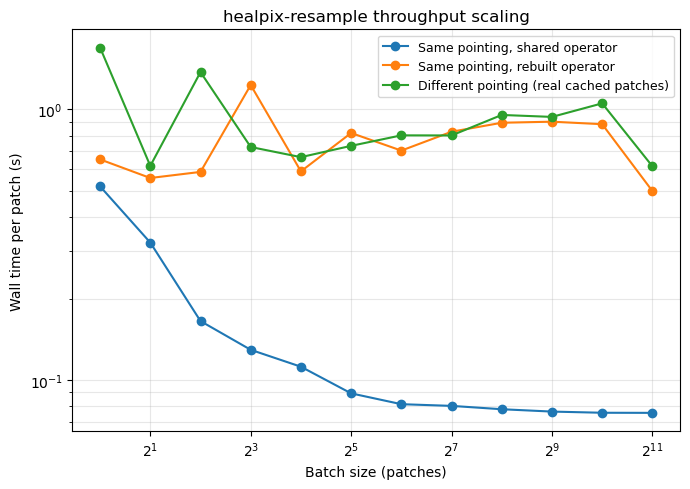

In [10]:
_REGIME_COLORS = {
    "same_pointing_shared": "tab:blue",
    "same_pointing_rebuilt": "tab:orange",
    "different_pointing": "tab:green",
}

grouped_time = (
    scaling_summary.groupby(["regime", "batch_size"], as_index=False)["s_per_item"].median()
)

fig, ax = plt.subplots(figsize=(7, 5))
for regime, color in _REGIME_COLORS.items():
    panel = grouped_time.loc[grouped_time["regime"].eq(regime)].sort_values("batch_size")
    if panel.empty:
        continue
    ax.plot(panel["batch_size"], panel["s_per_item"], marker="o", color=color,
            label=REGIME_LABELS[regime])
ax.set_xscale("log", base=2)
ax.set_yscale("log")
ax.set_xlabel("Batch size (patches)")
ax.set_ylabel("Wall time per patch (s)")
ax.set_title("healpix-resample throughput scaling")
ax.grid(alpha=0.3, which="both")
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig(FIG_DIR / "throughput_scaling_curve.pdf", bbox_inches="tight")


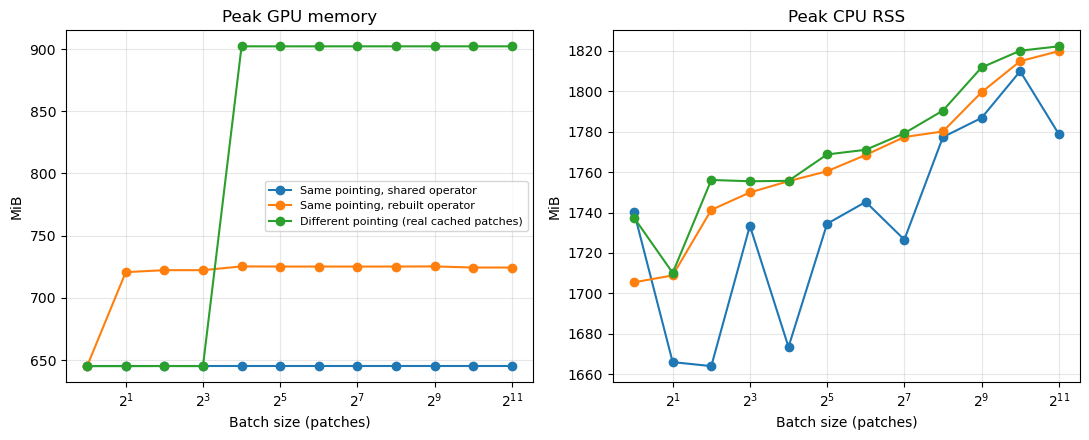

In [11]:
grouped_mem = (
    scaling_summary.groupby(["regime", "batch_size"], as_index=False)
    [["peak_gpu_memory_mib", "peak_rss_mib"]].median()
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for regime, color in _REGIME_COLORS.items():
    panel = grouped_mem.loc[grouped_mem["regime"].eq(regime)].sort_values("batch_size")
    if panel.empty:
        continue
    axes[0].plot(panel["batch_size"], panel["peak_gpu_memory_mib"], marker="o", color=color,
                 label=REGIME_LABELS[regime])
    axes[1].plot(panel["batch_size"], panel["peak_rss_mib"], marker="o", color=color,
                 label=REGIME_LABELS[regime])
for ax, title in zip(axes, ("Peak GPU memory", "Peak CPU RSS")):
    ax.set_xscale("log", base=2)
    ax.set_xlabel("Batch size (patches)")
    ax.set_ylabel("MiB")
    ax.set_title(title)
    ax.grid(alpha=0.3, which="both")
axes[0].legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / "throughput_scaling_memory.pdf", bbox_inches="tight")


## Reporting guidance

- All timing in this notebook is wall-clock (`time.perf_counter()`), with
  explicit CUDA synchronization immediately before and after each timed
  region, measured only here -- do not merge these numbers with the
  per-patch `operator_build_s`/`solve_s` figures from
  `multi_patch_latitude_validation.ipynb`; they are comparable in
  methodology but come from a separate run and separate process.
- `different_pointing` samples the cached pool **with replacement** once
  `batch_size` exceeds `pool_size`. Always check `unique_patches_used`
  against `pool_size` before citing a `different_pointing` number at a
  batch size larger than the cache -- it does not represent that many
  independent geographic patches.
- `same_pointing_shared` and `same_pointing_rebuilt` use synthetic per-item
  radiometric noise (SNR=100, white) purely to avoid re-solving on a
  bit-identical array; this is not a noise-robustness study (see
  `noise_sensitivity.ipynb` for that).
- This is a single-GPU, single-process, sequential benchmark. No
  multi-GPU, batched-tensor, or asynchronous-I/O execution path is tested;
  do not extrapolate these numbers to a multi-GPU or otherwise parallelized
  deployment without a dedicated benchmark.
- Do not extrapolate beyond the largest `batch_size` actually run in
  `BATCH_SIZES` -- GPU memory in particular may stop scaling linearly once
  it approaches device capacity, and this was not tested here.
- No reconstruction accuracy (RMSE, SSIM) is computed in this notebook by
  design; it answers "how fast", not "how accurate".
- Outputs: `tables/throughput_scaling_by_batch.csv` (one row per
  regime x batch_size x repeat), `tables/throughput_scaling_by_item.csv`
  (one row per individual build/solve), `tables/throughput_scaling_environment.csv`
  (one-row environment snapshot), `figures/throughput_scaling_curve.pdf`,
  `figures/throughput_scaling_memory.pdf`.
